[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-2/multiple-schemas.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239434-lesson-3-multiple-schemas)

# Multiple Schemas

## Review

We just covered state schema and reducers.

Typically, all graph nodes communicate with a single schema. 

Also, this single schema contains the graph's input and output keys / channels.

## Goals

But, there are cases where we may want a bit more control over this:

* Internal nodes may pass information that is *not required* in the graph's input / output.

* We may also want to use different input / output schemas for the graph. The output might, for example, only contain a single relevant output key.

We'll discuss a few ways to customize graphs with multiple schemas.

In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Private State

First, let's cover the case of passing [private state](https://docs.langchain.com/oss/python/langgraph/use-graph-api#pass-private-state-between-nodes) between nodes.

This is useful for anything needed as part of the intermediate working logic of the graph, but not relevant for the overall graph input or output.

We'll define an `OverallState` and a `PrivateState`.

`node_2` uses `PrivateState` as input, but writes out to `OverallState`.

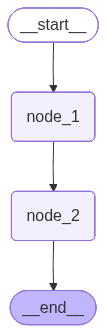

In [2]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

class OverallState(TypedDict):
    foo: int

class PrivateState(TypedDict):
    baz: int

def node_1(state: OverallState) -> PrivateState:
    print("---Node 1---")
    return {"baz": state['foo'] + 1}

def node_2(state: PrivateState) -> OverallState:
    print("---Node 2---")
    return {"foo": state['baz'] + 1}

# Build graph
builder = StateGraph(OverallState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
graph.invoke({"foo" : 1})

---Node 1---
---Node 2---


{'foo': 3}

`baz` is only included in `PrivateState`.

`node_2` uses `PrivateState` as input, but writes out to `OverallState`.

So, we can see that `baz` is excluded from the graph output because it is not in `OverallState`.

## Input / Output Schema

By default, `StateGraph` takes in a single schema and all nodes are expected to communicate with that schema. 

However, it is also possible to [define explicit input and output schemas for a graph](https://docs.langchain.com/oss/python/langgraph/use-graph-api#define-input-and-output-schemas).

In these cases, we often define an "internal" schema that contains *all* keys relevant to graph operations.

But we use specific `input` and `output` schemas to constrain the input and output.

First, let's just run the graph with a single schema.

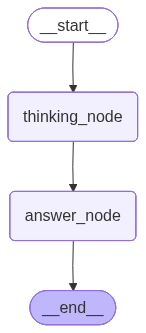

In [4]:
class OverallState(TypedDict):
    question: str
    answer: str
    notes: str

def thinking_node(state: OverallState):
    return {"answer": "bye", "notes": "... his name is Lance"}

def answer_node(state: OverallState):
    return {"answer": "bye Lance"}

graph = StateGraph(OverallState)
graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node", thinking_node)
graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph = graph.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

Notice that the output of invoke contains all keys in `OverallState`. 

In [5]:
graph.invoke({"question":"hi"})

{'question': 'hi', 'answer': 'bye Lance', 'notes': '... his name is Lance'}

Now, let's use a specific `input` and `output` schema with our graph.

Here, `input` / `output` schemas perform *filtering* on what keys are permitted on the input and output of the graph. 

In addition, we can use a type hint `state: InputState` to specify the input schema of each of our nodes.

This is important when the graph is using multiple schemas.

We use type hints below to, for example, show that the output of `answer_node` will be filtered to `OutputState`. 

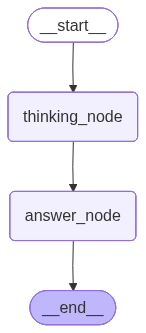

{'answer': 'bye Lance'}

In [6]:
class InputState(TypedDict):
    question: str

class OutputState(TypedDict):
    answer: str

class OverallState(TypedDict):
    question: str
    answer: str
    notes: str

def thinking_node(state: InputState):
    return {"answer": "bye", "notes": "... his is name is Lance"}

def answer_node(state: OverallState) -> OutputState:
    return {"answer": "bye Lance"}

graph = StateGraph(OverallState, input_schema=InputState, output_schema=OutputState)
graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node", thinking_node)
graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph = graph.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"question":"hi"})

We can see the `output` schema constrains the output to only the `answer` key.

In [12]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [13]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"




############################################
GRAPH VISUALIZATION
############################################


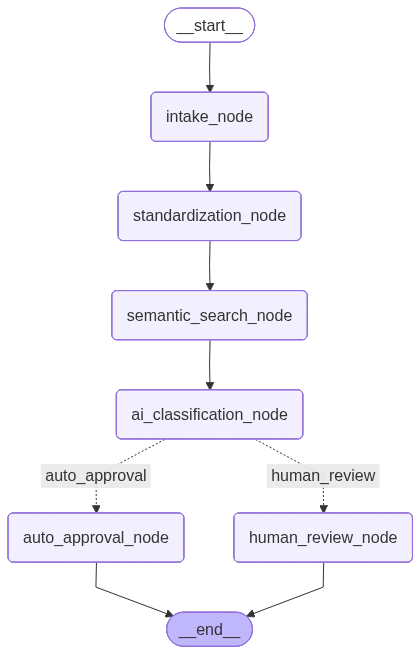




############################################
STARTING WARRANTY CLAIM AGENT WORKFLOW
############################################

NODE: CLAIM INTAKE
{'claim_no': 'CLM-1001',
 'fail_comment': 'ABS light intermittently active due to wiring issue',
 'vmrs_component': '013-004-001'}

NODE: STANDARDIZATION
{'claim_no': 'CLM-1001',
 'fail_comment': 'ABS light intermittently active due to wiring issue',
 'standard_problem_desc': 'ABS Wiring Harness Short',
 'vmrs_component': '013-004-001',
 'workflow_status': 'CLAIM_RECEIVED'}

NODE: SEMANTIC SEARCH
{'canonical_problem': 'ABS Wiring Harness Short',
 'claim_no': 'CLM-1001',
 'fail_comment': 'ABS light intermittently active due to wiring issue',
 'similarity_scores': [0.92, 0.85, 0.85],
 'standard_problem_desc': 'ABS Wiring Harness Short',
 'top_matches': ['ABS Wiring Harness Short - Historical Match 1',
                 'ABS Wiring Harness Short - Historical Match 2',
                 'ABS Wiring Harness Short - Historical Match 3'],
 'vmrs

In [15]:
# =========================================================
# LANGGRAPH ENTERPRISE WARRANTY AGENT
# FULL WORKING EXAMPLE WITH GRAPH VISUALIZATION
# =========================================================
#
# FEATURES:
# ---------------------------------------------------------
# 1. Multiple Schemas / Structured State
# 2. Stateful Workflow
# 3. Conditional Routing
# 4. Confidence-Based Decisions
# 5. Human Review Path
# 6. Graph Visualization
# 7. Stream Execution
# 8. Enterprise Agentic Pattern
#
# INSTALL:
# ---------------------------------------------------------
# pip install langgraph langchain pydantic ipython
#
# OPTIONAL (BETTER GRAPH VISUALS):
# pip install grandalf
#
# =========================================================


from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from pprint import pprint
import random
import json

# GRAPH VISUALIZATION
from IPython.display import Image, display


# =========================================================
# GLOBAL STATE SCHEMA
# =========================================================

class ClaimState(TypedDict, total=False):

    # -----------------------------------------------------
    # CLAIM INTAKE
    # -----------------------------------------------------

    claim_no: str
    fail_comment: str
    vmrs_component: str

    # -----------------------------------------------------
    # STANDARDIZATION
    # -----------------------------------------------------

    standard_problem_desc: str

    # -----------------------------------------------------
    # SEMANTIC SEARCH
    # -----------------------------------------------------

    canonical_problem: str
    top_matches: List[str]
    similarity_scores: List[float]

    # -----------------------------------------------------
    # AI CLASSIFICATION
    # -----------------------------------------------------

    responsible_party: str
    confidence: float
    reasoning: str

    # -----------------------------------------------------
    # WORKFLOW STATUS
    # -----------------------------------------------------

    requires_human_review: bool
    workflow_status: str


# =========================================================
# NODE 1 — CLAIM INTAKE
# =========================================================

def intake_node(state: ClaimState):

    print("\n==============================")
    print("NODE: CLAIM INTAKE")
    print("==============================")

    pprint(state)

    state["workflow_status"] = "CLAIM_RECEIVED"

    return state


# =========================================================
# NODE 2 — STANDARDIZATION
# =========================================================

def standardization_node(state: ClaimState):

    print("\n==============================")
    print("NODE: STANDARDIZATION")
    print("==============================")

    fail_comment = state["fail_comment"]

    # MOCK BUSINESS LOGIC

    if "abs" in fail_comment.lower():

        standard_problem = "ABS Wiring Harness Short"

    elif "paint" in fail_comment.lower():

        standard_problem = "Paint Surface Contamination"

    elif "leak" in fail_comment.lower():

        standard_problem = "Air System Leak"

    else:

        standard_problem = "General Component Failure"

    state["standard_problem_desc"] = standard_problem

    pprint(state)

    return state


# =========================================================
# NODE 3 — SEMANTIC SEARCH
# =========================================================

def semantic_search_node(state: ClaimState):

    print("\n==============================")
    print("NODE: SEMANTIC SEARCH")
    print("==============================")

    problem = state["standard_problem_desc"]

    # MOCK TOP-K RESULTS

    neighbors = [
        f"{problem} - Historical Match 1",
        f"{problem} - Historical Match 2",
        f"{problem} - Historical Match 3",
    ]

    similarities = [
        round(random.uniform(0.80, 0.98), 2),
        round(random.uniform(0.75, 0.95), 2),
        round(random.uniform(0.70, 0.90), 2),
    ]

    state["canonical_problem"] = problem
    state["top_matches"] = neighbors
    state["similarity_scores"] = similarities

    pprint(state)

    return state


# =========================================================
# NODE 4 — AI CLASSIFICATION
# =========================================================

def ai_classification_node(state: ClaimState):

    print("\n==============================")
    print("NODE: AI CLASSIFICATION")
    print("==============================")

    problem = state["canonical_problem"]

    # MOCK AI DECISIONING

    if "Wiring" in problem:

        responsible_party = "Supplier"
        confidence = 0.45
        reasoning = (
            "Repeated supplier harness failures "
            "observed historically."
        )

    elif "Paint" in problem:

        responsible_party = "Transporter"
        confidence = 0.72
        reasoning = (
            "Paint contamination commonly occurs "
            "during transportation."
        )

    elif "Leak" in problem:

        responsible_party = "Manufacturing"
        confidence = 0.83
        reasoning = (
            "Assembly process likely caused "
            "improper fitting."
        )

    else:

        responsible_party = "Manufacturing"
        confidence = 0.65
        reasoning = (
            "Insufficient evidence for high-confidence "
            "classification."
        )

    state["responsible_party"] = responsible_party
    state["confidence"] = confidence
    state["reasoning"] = reasoning

    pprint(state)

    return state


# =========================================================
# NODE 5 — HUMAN REVIEW
# =========================================================

def human_review_node(state: ClaimState):

    print("\n==============================")
    print("NODE: HUMAN REVIEW")
    print("==============================")

    state["workflow_status"] = "PENDING_HUMAN_REVIEW"

    pprint(state)

    return state


# =========================================================
# NODE 6 — AUTO APPROVAL
# =========================================================

def auto_approval_node(state: ClaimState):

    print("\n==============================")
    print("NODE: AUTO APPROVAL")
    print("==============================")

    state["workflow_status"] = "AUTO_APPROVED"

    pprint(state)

    return state


# =========================================================
# CONDITIONAL ROUTING LOGIC
# =========================================================

def route_after_classification(state: ClaimState):

    print("\n==============================")
    print("ROUTING DECISION")
    print("==============================")

    confidence = state["confidence"]

    print(f"Confidence Score: {confidence}")

    if confidence >= 0.85:

        print("ROUTING TO → AUTO APPROVAL")

        return "auto_approval"

    else:

        print("ROUTING TO → HUMAN REVIEW")

        return "human_review"


# =========================================================
# BUILD GRAPH
# =========================================================

graph = StateGraph(ClaimState)


# =========================================================
# REGISTER NODES
# =========================================================

graph.add_node("intake_node", intake_node)

graph.add_node(
    "standardization_node",
    standardization_node
)

graph.add_node(
    "semantic_search_node",
    semantic_search_node
)

graph.add_node(
    "ai_classification_node",
    ai_classification_node
)

graph.add_node(
    "human_review_node",
    human_review_node
)

graph.add_node(
    "auto_approval_node",
    auto_approval_node
)


# =========================================================
# ENTRY POINT
# =========================================================

graph.set_entry_point("intake_node")


# =========================================================
# NORMAL EDGES
# =========================================================

graph.add_edge(
    "intake_node",
    "standardization_node"
)

graph.add_edge(
    "standardization_node",
    "semantic_search_node"
)

graph.add_edge(
    "semantic_search_node",
    "ai_classification_node"
)


# =========================================================
# CONDITIONAL EDGES
# =========================================================

graph.add_conditional_edges(
    "ai_classification_node",
    route_after_classification,
    {
        "auto_approval": "auto_approval_node",
        "human_review": "human_review_node",
    },
)


# =========================================================
# END STATES
# =========================================================

graph.add_edge(
    "auto_approval_node",
    END
)

graph.add_edge(
    "human_review_node",
    END
)


# =========================================================
# COMPILE GRAPH
# =========================================================

app = graph.compile()


# =========================================================
# VISUALIZE GRAPH
# =========================================================

print("\n\n")
print("############################################")
print("GRAPH VISUALIZATION")
print("############################################")

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)


# =========================================================
# TEST INPUT
# =========================================================

input_claim = {
    "claim_no": "CLM-1001",
    "fail_comment":
        "ABS light intermittently active due to wiring issue",
    "vmrs_component": "013-004-001"
}


# =========================================================
# EXECUTE GRAPH
# =========================================================

print("\n\n")
print("############################################")
print("STARTING WARRANTY CLAIM AGENT WORKFLOW")
print("############################################")

result = app.invoke(input_claim)


# =========================================================
# FINAL RESULT
# =========================================================

print("\n\n")
print("############################################")
print("FINAL WORKFLOW RESULT")
print("############################################")

print(
    json.dumps(
        result,
        indent=2
    )
)


# =========================================================
# STREAM EXECUTION (ADVANCED)
# =========================================================

print("\n\n")
print("############################################")
print("STREAMING NODE EXECUTION")
print("############################################")

for step in app.stream(input_claim):

    print("\n-----------------------------------")
    print(json.dumps(step, indent=2))


# =========================================================
# ASCII GRAPH (OPTIONAL)
# =========================================================

print("\n\n")
print("############################################")
print("ASCII GRAPH")
print("############################################")

try:

    print(app.get_graph().draw_ascii())

except Exception as e:

    print("Install grandalf for ASCII graphs:")
    print("pip install grandalf")




############################################
GRAPH VISUALIZATION
############################################


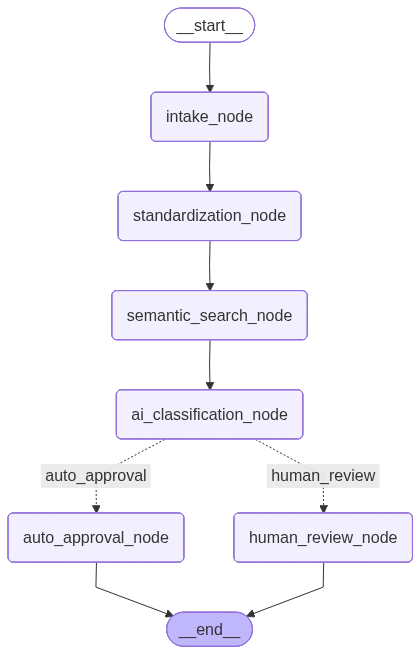




############################################
STARTING WORKFLOW EXECUTION
############################################

NODE EXECUTED → CLAIM INTAKE
{'claim_no': 'CLM-1001',
 'fail_comment': 'Paint damaged during transportation',
 'vmrs_component': '002-001-001'}

NODE EXECUTED → STANDARDIZATION
{'claim_no': 'CLM-1001',
 'fail_comment': 'Paint damaged during transportation',
 'standard_problem_desc': 'Paint Surface Contamination',
 'vmrs_component': '002-001-001',
 'workflow_status': 'CLAIM_RECEIVED'}

NODE EXECUTED → SEMANTIC SEARCH
{'canonical_problem': 'Paint Surface Contamination',
 'claim_no': 'CLM-1001',
 'fail_comment': 'Paint damaged during transportation',
 'similarity_scores': [0.93, 0.85, 0.74],
 'standard_problem_desc': 'Paint Surface Contamination',
 'top_matches': ['Paint Surface Contamination - Historical Match 1',
                 'Paint Surface Contamination - Historical Match 2',
                 'Paint Surface Contamination - Historical Match 3'],
 'vmrs_component'

In [16]:
# =========================================================
# LANGGRAPH + LANGSMITH
# ENTERPRISE WARRANTY AGENT
# FULL WORKING END-TO-END EXAMPLE
# =========================================================

# =========================================================
# INSTALL REQUIRED PACKAGES
# =========================================================
#
# pip install langgraph
# pip install langchain
# pip install langsmith
# pip install ipython
# pip install grandalf
#
# =========================================================


# =========================================================
# ENVIRONMENT VARIABLES
# =========================================================

import os
import getpass

def _set_env(var: str):

    if not os.environ.get(var):

        os.environ[var] = getpass.getpass(f"{var}: ")


# ---------------------------------------------------------
# OPENAI API KEY
# ---------------------------------------------------------

_set_env("OPENAI_API_KEY")


# ---------------------------------------------------------
# LANGSMITH API KEY
# ---------------------------------------------------------

_set_env("LANGSMITH_API_KEY")


# ---------------------------------------------------------
# ENABLE LANGSMITH TRACING
# ---------------------------------------------------------

os.environ["LANGCHAIN_TRACING_V2"] = "true"


# ---------------------------------------------------------
# LANGSMITH PROJECT NAME
# ---------------------------------------------------------

os.environ["LANGSMITH_PROJECT"] = "Warranty-Agent-POC"


# =========================================================
# IMPORTS
# =========================================================

from typing import TypedDict, List

from langgraph.graph import StateGraph, END

from pprint import pprint

from IPython.display import Image, display

from langsmith import traceable

import random
import json


# =========================================================
# GLOBAL STATE SCHEMA
# =========================================================

class ClaimState(TypedDict, total=False):

    # -----------------------------------------------------
    # CLAIM INTAKE
    # -----------------------------------------------------

    claim_no: str

    fail_comment: str

    vmrs_component: str


    # -----------------------------------------------------
    # STANDARDIZATION
    # -----------------------------------------------------

    standard_problem_desc: str


    # -----------------------------------------------------
    # SEMANTIC SEARCH
    # -----------------------------------------------------

    canonical_problem: str

    top_matches: List[str]

    similarity_scores: List[float]


    # -----------------------------------------------------
    # AI CLASSIFICATION
    # -----------------------------------------------------

    responsible_party: str

    confidence: float

    reasoning: str


    # -----------------------------------------------------
    # WORKFLOW STATUS
    # -----------------------------------------------------

    workflow_status: str


# =========================================================
# NODE 1 — CLAIM INTAKE
# =========================================================

@traceable
def intake_node(state: ClaimState):

    print("\n====================================")
    print("NODE EXECUTED → CLAIM INTAKE")
    print("====================================")

    pprint(state)

    state["workflow_status"] = "CLAIM_RECEIVED"

    return state


# =========================================================
# NODE 2 — STANDARDIZATION
# =========================================================

@traceable
def standardization_node(state: ClaimState):

    print("\n====================================")
    print("NODE EXECUTED → STANDARDIZATION")
    print("====================================")

    fail_comment = state["fail_comment"]


    # -----------------------------------------------------
    # MOCK BUSINESS LOGIC
    # -----------------------------------------------------

    if "abs" in fail_comment.lower():

        standard_problem = "ABS Wiring Harness Short"

    elif "paint" in fail_comment.lower():

        standard_problem = "Paint Surface Contamination"

    elif "leak" in fail_comment.lower():

        standard_problem = "Air System Leak"

    else:

        standard_problem = "General Component Failure"


    state["standard_problem_desc"] = standard_problem

    pprint(state)

    return state


# =========================================================
# NODE 3 — SEMANTIC SEARCH
# =========================================================

@traceable
def semantic_search_node(state: ClaimState):

    print("\n====================================")
    print("NODE EXECUTED → SEMANTIC SEARCH")
    print("====================================")

    problem = state["standard_problem_desc"]


    # -----------------------------------------------------
    # MOCK TOP-K NEIGHBORS
    # -----------------------------------------------------

    neighbors = [

        f"{problem} - Historical Match 1",

        f"{problem} - Historical Match 2",

        f"{problem} - Historical Match 3",
    ]


    similarities = [

        round(random.uniform(0.80, 0.98), 2),

        round(random.uniform(0.75, 0.95), 2),

        round(random.uniform(0.70, 0.90), 2),
    ]


    state["canonical_problem"] = problem

    state["top_matches"] = neighbors

    state["similarity_scores"] = similarities

    pprint(state)

    return state


# =========================================================
# NODE 4 — AI CLASSIFICATION
# =========================================================

@traceable
def ai_classification_node(state: ClaimState):

    print("\n====================================")
    print("NODE EXECUTED → AI CLASSIFICATION")
    print("====================================")

    problem = state["canonical_problem"]


    # -----------------------------------------------------
    # MOCK AI DECISIONING
    # -----------------------------------------------------

    if "Wiring" in problem:

        responsible_party = "Supplier"

        confidence = 0.92

        reasoning = (
            "Repeated supplier harness failures "
            "observed historically."
        )

    elif "Paint" in problem:

        responsible_party = "Transporter"

        confidence = 0.72

        reasoning = (
            "Paint contamination commonly occurs "
            "during transportation."
        )

    elif "Leak" in problem:

        responsible_party = "Manufacturing"

        confidence = 0.83

        reasoning = (
            "Assembly process likely caused "
            "improper fitting."
        )

    else:

        responsible_party = "Manufacturing"

        confidence = 0.55

        reasoning = (
            "Low confidence classification."
        )


    state["responsible_party"] = responsible_party

    state["confidence"] = confidence

    state["reasoning"] = reasoning

    pprint(state)

    return state


# =========================================================
# NODE 5 — HUMAN REVIEW
# =========================================================

@traceable
def human_review_node(state: ClaimState):

    print("\n")
    print("########################################")
    print("HUMAN REVIEW NODE EXECUTED")
    print("########################################")

    state["workflow_status"] = "PENDING_HUMAN_REVIEW"

    pprint(state)

    return state


# =========================================================
# NODE 6 — AUTO APPROVAL
# =========================================================

@traceable
def auto_approval_node(state: ClaimState):

    print("\n")
    print("########################################")
    print("AUTO APPROVAL NODE EXECUTED")
    print("########################################")

    state["workflow_status"] = "AUTO_APPROVED"

    pprint(state)

    return state


# =========================================================
# CONDITIONAL ROUTING LOGIC
# =========================================================

@traceable
def route_after_classification(state: ClaimState):

    print("\n====================================")
    print("ROUTING DECISION")
    print("====================================")

    confidence = state["confidence"]

    print(f"CONFIDENCE SCORE → {confidence}")


    # -----------------------------------------------------
    # ROUTING LOGIC
    # -----------------------------------------------------

    if confidence >= 0.85:

        print("ROUTING TO → AUTO APPROVAL")

        return "auto_approval"

    else:

        print("ROUTING TO → HUMAN REVIEW")

        return "human_review"


# =========================================================
# BUILD GRAPH
# =========================================================

graph = StateGraph(ClaimState)


# =========================================================
# REGISTER NODES
# =========================================================

graph.add_node(
    "intake_node",
    intake_node
)

graph.add_node(
    "standardization_node",
    standardization_node
)

graph.add_node(
    "semantic_search_node",
    semantic_search_node
)

graph.add_node(
    "ai_classification_node",
    ai_classification_node
)

graph.add_node(
    "human_review_node",
    human_review_node
)

graph.add_node(
    "auto_approval_node",
    auto_approval_node
)


# =========================================================
# ENTRY POINT
# =========================================================

graph.set_entry_point("intake_node")


# =========================================================
# NORMAL EDGES
# =========================================================

graph.add_edge(
    "intake_node",
    "standardization_node"
)

graph.add_edge(
    "standardization_node",
    "semantic_search_node"
)

graph.add_edge(
    "semantic_search_node",
    "ai_classification_node"
)


# =========================================================
# CONDITIONAL EDGES
# =========================================================

graph.add_conditional_edges(
    "ai_classification_node",
    route_after_classification,
    {
        "auto_approval": "auto_approval_node",

        "human_review": "human_review_node",
    },
)


# =========================================================
# END STATES
# =========================================================

graph.add_edge(
    "auto_approval_node",
    END
)

graph.add_edge(
    "human_review_node",
    END
)


# =========================================================
# COMPILE GRAPH
# =========================================================

app = graph.compile()


# =========================================================
# VISUALIZE GRAPH
# =========================================================

print("\n\n")
print("############################################")
print("GRAPH VISUALIZATION")
print("############################################")

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)


# =========================================================
# TEST CLAIM INPUT
# =========================================================

input_claim = {

    "claim_no": "CLM-1001",

    "fail_comment":
        "Paint damaged during transportation",

    "vmrs_component": "002-001-001"
}


# =========================================================
# EXECUTE GRAPH
# =========================================================

print("\n\n")
print("############################################")
print("STARTING WORKFLOW EXECUTION")
print("############################################")

result = app.invoke(input_claim)


# =========================================================
# FINAL RESULT
# =========================================================

print("\n\n")
print("############################################")
print("FINAL WORKFLOW RESULT")
print("############################################")

print(
    json.dumps(
        result,
        indent=2
    )
)


# =========================================================
# STREAM EXECUTION
# =========================================================

print("\n\n")
print("############################################")
print("STREAM EXECUTION TRACE")
print("############################################")

for step in app.stream(input_claim):

    node_name = list(step.keys())[0]

    print("\n====================================")
    print(f"EXECUTED NODE → {node_name}")
    print("====================================")

    print(
        json.dumps(
            step,
            indent=2
        )
    )


# =========================================================
# ASCII GRAPH
# =========================================================

print("\n\n")
print("############################################")
print("ASCII GRAPH")
print("############################################")

try:

    print(
        app.get_graph().draw_ascii()
    )

except Exception as e:

    print("\nInstall grandalf for ASCII graphs:")
    print("pip install grandalf")


# =========================================================
# LANGSMITH
# =========================================================

print("\n\n")
print("############################################")
print("LANGSMITH TRACE")
print("############################################")

print(
    "Open LangSmith dashboard and check project:"
)

print(
    "Warranty-Agent-POC"
)